# 04bis — Cn_beta Surrogate Study

The main surrogate (04) achieves R²=0.67 on Cn_beta — insufficient.
This notebook tests two improvement strategies:

1. **Dedicated model** — deeper MLP and XGBoost trained on Cn_beta only
2. **Lateral-specific features** — winglet area, lateral lever arm, vertical tail volume coefficient, etc.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import skew, kurtosis

from src.surrogate.model import PRIMITIVE_TARGETS, _TARGET_CLIP
from src.surrogate.features import (
    augment_features,
    _IDX_HALF_SPAN, _IDX_WING_ROOT_CHORD, _IDX_TAPER_RATIO,
    _IDX_LE_SWEEP_DEG, _IDX_BODY_CHORD_RATIO, _IDX_BODY_HALFWIDTH,
    _IDX_BODY_TC_ROOT, _IDX_BODY_SWEEP_DELTA,
    _IDX_DIHEDRAL, _IDX_TWIST, _IDX_TWIST_TIP,
    _DIHEDRAL_SEGMENTS,
)
from src.optimization.database import EvaluationDatabase

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [ ]:
%load_ext autoreload
%autoreload 2

## 1. Load & filter clean dataset

In [2]:
db = EvaluationDatabase.load('../data/eval_database.json')
X_arr, results = db.to_arrays()

# Extract targets
Y_rows, valid_idx = [], []
for i, r in enumerate(results):
    if not r.get('success', True):
        continue
    alpha_eq_rad = np.radians(r.get('alpha_eq', 0.0))
    cl_alpha = r.get('CL_alpha', 0.0)
    cm_alpha = r.get('CM_alpha', 0.0)
    cl_0 = r.get('CL_0', None)
    if cl_0 is None:
        cl_0 = r.get('CL_required', 0.0) - cl_alpha * alpha_eq_rad
    cm_0 = r.get('CM_0', None)
    if cm_0 is None:
        cm_0 = r.get('CM', 0.0) - cm_alpha * alpha_eq_rad
    cd0_wing = r.get('CD0_wing', r.get('CD0', 0.008) * 0.6)
    cd0_body = r.get('CD0_body', r.get('CD0', 0.008) * 0.4)
    cn_beta = r.get('Cn_beta', 0.0)
    Y_rows.append([cl_0, cl_alpha, cm_0, cm_alpha, cd0_wing, cd0_body, cn_beta])
    valid_idx.append(i)

Y_all = np.array(Y_rows)
X_valid = X_arr[valid_idx]

# Apply _TARGET_CLIP
mask = np.ones(len(Y_all), dtype=bool)
for j, key in enumerate(PRIMITIVE_TARGETS):
    lo, hi = _TARGET_CLIP[key]
    mask &= (Y_all[:, j] >= lo) & (Y_all[:, j] <= hi)

X_clean = X_valid[mask]
y_cn = Y_all[mask, 6]  # Cn_beta only

print(f'Clean samples: {len(y_cn)}')
print(f'Cn_beta  mean={y_cn.mean():.4f}  std={y_cn.std():.4f}  '
      f'skew={skew(y_cn):.2f}  kurt={kurtosis(y_cn):.2f}')
print(f'         min={y_cn.min():.4f}  max={y_cn.max():.4f}')

Clean samples: 3468
Cn_beta  mean=-0.0732  std=1.1593  skew=-0.38  kurt=5.79
         min=-4.9789  max=4.9877


## 2. Lateral-specific features for Cn_beta

Cn_beta (yaw stability) depends on:
- Winglet geometry (effective vertical tail area, lever arm)
- Body side area and lateral centroid
- Sweep (weathercock effect)
- Dihedral-yaw coupling

In [3]:
def augment_lateral_features(X: np.ndarray) -> np.ndarray:
    """Add lateral-stability-specific features on top of standard augmentation.
    
    Returns (N, 52 + n_lateral) feature matrix.
    """
    X_aug = augment_features(X)  # (N, 52)
    
    # Raw variables
    hs = X[:, _IDX_HALF_SPAN]
    rc = X[:, _IDX_WING_ROOT_CHORD]
    tr = X[:, _IDX_TAPER_RATIO]
    sweep_deg = X[:, _IDX_LE_SWEEP_DEG]
    sweep_rad = np.radians(sweep_deg)
    bcr = X[:, _IDX_BODY_CHORD_RATIO]
    bw = X[:, _IDX_BODY_HALFWIDTH]
    btc = X[:, _IDX_BODY_TC_ROOT]
    bsd = X[:, _IDX_BODY_SWEEP_DELTA]
    dihedrals = X[:, _IDX_DIHEDRAL]  # (N, 5)
    dih_tip_deg = dihedrals[:, -1]    # dihedral_tip
    dih_tip_rad = np.radians(dih_tip_deg)
    
    tip_chord = rc * tr
    body_root_chord = rc * bcr
    outer_span = hs - bw
    
    # --- Winglet-related features ---
    # Winglet projected vertical height (last dihedral segment)
    winglet_span_frac = _DIHEDRAL_SEGMENTS[-1]  # 0.10
    winglet_semispan = outer_span * winglet_span_frac
    winglet_height = winglet_semispan * np.sin(dih_tip_rad)
    
    # Winglet chord at base and tip
    # Linear taper: chord at winglet base ~ rc * (1 - (1-tr) * 0.90)
    winglet_base_frac = 1.0 - sum(_DIHEDRAL_SEGMENTS[:-1])  # 0.10 from tip
    chord_at_winglet_base = rc * (1.0 - (1.0 - tr) * (1.0 - winglet_span_frac))
    chord_at_tip = tip_chord
    
    # Winglet projected side area (vertical projection)
    winglet_area = 0.5 * (chord_at_winglet_base + chord_at_tip) * winglet_height
    
    # Winglet lever arm (distance from CG to winglet centroid, along span)
    # CG ~ 0.25 * MAC from LE at ~40% span
    winglet_y_pos = hs - 0.5 * winglet_semispan  # midpoint of winglet
    winglet_x_pos = winglet_y_pos * np.tan(sweep_rad) + 0.5 * chord_at_winglet_base
    cg_x_approx = 0.35 * body_root_chord  # rough CG position
    winglet_lever_arm = winglet_x_pos - cg_x_approx
    
    # Vertical tail volume coefficient analog
    wing_area = (body_root_chord + rc) * bw + (rc + tip_chord) * outer_span
    mac = (2 / 3) * rc * (1 + tr + tr**2) / (1 + tr)
    Vv = winglet_area * winglet_lever_arm / np.maximum(wing_area * (2 * hs), 1e-8)
    
    # --- Body side area (destabilizing in yaw) ---
    body_side_area = body_root_chord * btc * body_root_chord * 0.5  # rough projected area
    body_lever_arm = 0.5 * body_root_chord - cg_x_approx  # body centroid ahead of CG
    body_yaw_moment = body_side_area * body_lever_arm  # destabilizing
    
    # --- Sweep contribution to yaw stability ---
    # CL * tan(sweep) effect: higher sweep -> more Cn_beta
    sweep_yaw_factor = np.tan(sweep_rad) * wing_area
    
    # --- Dihedral-yaw coupling ---
    # Effective dihedral (mean weighted by segment span)
    dih_rad = np.radians(dihedrals)
    seg_lengths = outer_span[:, None] * _DIHEDRAL_SEGMENTS
    mean_dihedral = (dih_rad * seg_lengths).sum(axis=1) / np.maximum(outer_span, 1e-6)
    
    # Dihedral effect on Cn_beta (through Cl_beta coupling)
    dihedral_yaw_coupling = mean_dihedral * np.tan(sweep_rad)
    
    # --- Ratios ---
    winglet_area_ratio = winglet_area / np.maximum(wing_area, 1e-8)
    body_to_winglet_ratio = body_side_area / np.maximum(winglet_area + 1e-8, 1e-8)
    
    # --- Stack lateral features ---
    lateral_features = np.column_stack([
        winglet_height,          # 52
        winglet_area,            # 53
        winglet_lever_arm,       # 54
        Vv,                      # 55 - vertical tail volume coeff
        body_side_area,          # 56
        body_yaw_moment,         # 57
        sweep_yaw_factor,        # 58
        mean_dihedral,           # 59
        dihedral_yaw_coupling,   # 60
        winglet_area_ratio,      # 61
        body_to_winglet_ratio,   # 62
    ])
    
    LATERAL_FEATURE_NAMES = [
        'winglet_height', 'winglet_area', 'winglet_lever_arm',
        'Vv_coeff', 'body_side_area', 'body_yaw_moment',
        'sweep_yaw_factor', 'mean_dihedral', 'dihedral_yaw_coupling',
        'winglet_area_ratio', 'body_to_winglet_ratio',
    ]
    
    return np.column_stack([X_aug, lateral_features]), LATERAL_FEATURE_NAMES


X_lat, lat_names = augment_lateral_features(X_clean)
print(f'Features: 30 raw -> 52 standard -> {X_lat.shape[1]} with lateral')
print(f'New lateral features: {lat_names}')

# Check for NaN/Inf
print(f'NaN: {np.isnan(X_lat).sum()}  Inf: {np.isinf(X_lat).sum()}')

# Correlation with Cn_beta
print(f'\nCorrelation with Cn_beta:')
for i, name in enumerate(lat_names):
    col = X_lat[:, 52 + i]
    r = np.corrcoef(col, y_cn)[0, 1]
    print(f'  {name:<25s}  r = {r:+.4f}')

Features: 30 raw -> 52 standard -> 63 with lateral
New lateral features: ['winglet_height', 'winglet_area', 'winglet_lever_arm', 'Vv_coeff', 'body_side_area', 'body_yaw_moment', 'sweep_yaw_factor', 'mean_dihedral', 'dihedral_yaw_coupling', 'winglet_area_ratio', 'body_to_winglet_ratio']
NaN: 0  Inf: 0

Correlation with Cn_beta:
  winglet_height             r = -0.0047
  winglet_area               r = -0.0271
  winglet_lever_arm          r = +0.0506
  Vv_coeff                   r = +0.0004
  body_side_area             r = -0.0494
  body_yaw_moment            r = -0.0464
  sweep_yaw_factor           r = +0.0054
  mean_dihedral              r = +0.0213
  dihedral_yaw_coupling      r = +0.0305
  winglet_area_ratio         r = -0.0338
  body_to_winglet_ratio      r = +0.0028


## 3. Baseline — Current MLP ensemble (R² from notebook 04)

In [4]:
from src.surrogate.model import SurrogateModel

surrogate_base = SurrogateModel.load('../models/surrogate_v2')
preds_base = surrogate_base.predict(X_clean)
y_pred_base = preds_base['Cn_beta']

ss_res = np.sum((y_cn - y_pred_base)**2)
ss_tot = np.sum((y_cn - y_cn.mean())**2)
r2_base = 1 - ss_res / ss_tot
mae_base = np.mean(np.abs(y_cn - y_pred_base))
print(f'Baseline (shared MLP ensemble): R² = {r2_base:.4f}, MAE = {mae_base:.4f}')

Baseline (shared MLP ensemble): R² = 0.6739, MAE = 0.3622


## 4. Strategy A — Dedicated deeper MLP for Cn_beta

Test with:
- Standard features (52)
- Standard + lateral features (63)
- Deeper architectures: 256-256-128-64, 512-256-128

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def train_single_mlp(X_train, y_train, X_val, y_val, layers, 
                     epochs=500, lr=3e-3, wd=1e-4, patience=50, dropout=0.05):
    """Train a single MLP on Cn_beta (1 output)."""
    n_in = X_train.shape[1]
    
    # Build network
    dims = [n_in, *layers, 1]
    modules = []
    for i in range(len(dims) - 1):
        modules.append(nn.Linear(dims[i], dims[i + 1]))
        if i < len(dims) - 2:
            modules.append(nn.BatchNorm1d(dims[i + 1]))
            modules.append(nn.SiLU())
            if dropout > 0:
                modules.append(nn.Dropout(dropout))
    model = nn.Sequential(*modules).to(device)
    
    X_tr_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32, device=device)
    X_va_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_va_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32, device=device)
    
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), 
                        batch_size=min(512, len(X_train)), shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=15, min_lr=1e-6)
    
    best_val = float('inf')
    wait = 0
    best_state = None
    
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            loss = nn.functional.mse_loss(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = nn.functional.mse_loss(model(X_va_t), y_va_t).item()
        scheduler.step(val_loss)
        
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model, best_val


def cv_evaluate(X_feat, y, layers, n_splits=5, **train_kwargs):
    """5-fold CV evaluation. Returns per-fold R² and MAE."""
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    r2_folds, mae_folds = [], []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_feat)):
        X_tr, X_va = X_feat[train_idx], X_feat[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]
        
        scX = StandardScaler().fit(X_tr)
        scy = StandardScaler().fit(y_tr.reshape(-1, 1))
        
        X_tr_s = scX.transform(X_tr)
        X_va_s = scX.transform(X_va)
        y_tr_s = scy.transform(y_tr.reshape(-1, 1)).ravel()
        y_va_s = scy.transform(y_va.reshape(-1, 1)).ravel()
        
        model, _ = train_single_mlp(X_tr_s, y_tr_s, X_va_s, y_va_s, 
                                     layers, **train_kwargs)
        
        with torch.no_grad():
            X_va_t = torch.tensor(X_va_s, dtype=torch.float32, device=device)
            y_pred_s = model(X_va_t).cpu().numpy().ravel()
        y_pred = scy.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
        
        ss_res = np.sum((y_va - y_pred)**2)
        ss_tot = np.sum((y_va - y_va.mean())**2)
        r2 = 1 - ss_res / ss_tot
        mae = np.mean(np.abs(y_va - y_pred))
        r2_folds.append(r2)
        mae_folds.append(mae)
    
    return np.array(r2_folds), np.array(mae_folds)

print('Training utilities ready.')

Device: cuda
Training utilities ready.


In [6]:
# Prepare feature sets
X_std = augment_features(X_clean)  # (N, 52)
X_lat, _ = augment_lateral_features(X_clean)  # (N, 63)

configs = [
    # (name, features, architecture)
    ('MLP 256-128-64 (std)',          X_std, (256, 128, 64)),
    ('MLP 256-128-64 (lateral)',      X_lat, (256, 128, 64)),
    ('MLP 256-256-128-64 (std)',      X_std, (256, 256, 128, 64)),
    ('MLP 256-256-128-64 (lateral)',  X_lat, (256, 256, 128, 64)),
    ('MLP 512-256-128 (std)',         X_std, (512, 256, 128)),
    ('MLP 512-256-128 (lateral)',     X_lat, (512, 256, 128)),
]

print(f'{"Config":<36s}  {"R² mean":>8s} {"R² std":>7s}  {"MAE mean":>9s}')
print('-' * 70)

mlp_results = {}
for name, X_feat, layers in configs:
    r2s, maes = cv_evaluate(X_feat, y_cn, layers, epochs=500, patience=50)
    mlp_results[name] = (r2s, maes)
    print(f'{name:<36s}  {r2s.mean():>8.4f} {r2s.std():>7.4f}  {maes.mean():>9.4f}')

Config                                 R² mean  R² std   MAE mean
----------------------------------------------------------------------
MLP 256-128-64 (std)                    0.0106  0.0169     0.6557
MLP 256-128-64 (lateral)                0.0122  0.0103     0.6410
MLP 256-256-128-64 (std)                0.0133  0.0099     0.6385
MLP 256-256-128-64 (lateral)            0.0143  0.0113     0.6332
MLP 512-256-128 (std)                   0.0028  0.0197     0.6596
MLP 512-256-128 (lateral)              -0.0012  0.0266     0.6614


## 5. Strategy B — XGBoost for Cn_beta

In [7]:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    HAS_XGB = False

if HAS_XGB:
    xgb_configs = [
        ('XGB default (std)',    X_std, {}),
        ('XGB default (lateral)', X_lat, {}),
        ('XGB deep (std)',       X_std, {'max_depth': 8, 'n_estimators': 500, 
                                         'learning_rate': 0.05, 'subsample': 0.8,
                                         'colsample_bytree': 0.8}),
        ('XGB deep (lateral)',   X_lat, {'max_depth': 8, 'n_estimators': 500,
                                         'learning_rate': 0.05, 'subsample': 0.8,
                                         'colsample_bytree': 0.8}),
        ('XGB tuned (lateral)',  X_lat, {'max_depth': 6, 'n_estimators': 1000,
                                         'learning_rate': 0.03, 'subsample': 0.8,
                                         'colsample_bytree': 0.7, 'reg_alpha': 0.1,
                                         'reg_lambda': 1.0, 'min_child_weight': 5}),
    ]
    
    print(f'{"Config":<36s}  {"R² mean":>8s} {"R² std":>7s}  {"MAE mean":>9s}')
    print('-' * 70)
    
    xgb_results = {}
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    for name, X_feat, params in xgb_configs:
        r2_folds, mae_folds = [], []
        for train_idx, val_idx in kf.split(X_feat):
            X_tr, X_va = X_feat[train_idx], X_feat[val_idx]
            y_tr, y_va = y_cn[train_idx], y_cn[val_idx]
            
            xgb = XGBRegressor(**params, random_state=42, verbosity=0)
            xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            
            y_pred = xgb.predict(X_va)
            ss_res = np.sum((y_va - y_pred)**2)
            ss_tot = np.sum((y_va - y_va.mean())**2)
            r2_folds.append(1 - ss_res / ss_tot)
            mae_folds.append(np.mean(np.abs(y_va - y_pred)))
        
        r2s = np.array(r2_folds)
        maes = np.array(mae_folds)
        xgb_results[name] = (r2s, maes)
        print(f'{name:<36s}  {r2s.mean():>8.4f} {r2s.std():>7.4f}  {maes.mean():>9.4f}')

Config                                 R² mean  R² std   MAE mean
----------------------------------------------------------------------
XGB default (std)                      -0.1703  0.0367     0.7771
XGB default (lateral)                  -0.1961  0.0512     0.7859
XGB deep (std)                         -0.0482  0.0290     0.6872
XGB deep (lateral)                     -0.0450  0.0413     0.6844
XGB tuned (lateral)                    -0.0603  0.0380     0.6994


## 6. Comparison — All approaches

In [8]:
# Gather all results
all_results = {}
all_results['Baseline (shared MLP)'] = (np.array([r2_base]), np.array([mae_base]))
all_results.update(mlp_results)
if HAS_XGB:
    all_results.update(xgb_results)

# Sort by R²
sorted_results = sorted(all_results.items(), key=lambda x: x[1][0].mean(), reverse=True)

print(f'\n{"="*75}')
print(f'{"Cn_beta Surrogate Comparison":^75}')
print(f'{"="*75}')
print(f'{"Config":<36s}  {"R² mean":>8s} {"R² std":>7s}  {"MAE":>8s}  {"vs base":>8s}')
print(f'{"-"*75}')
for name, (r2s, maes) in sorted_results:
    delta = r2s.mean() - r2_base
    marker = ' <-- best' if name == sorted_results[0][0] else ''
    print(f'{name:<36s}  {r2s.mean():>8.4f} {r2s.std():>7.4f}  '
          f'{maes.mean():>8.4f}  {delta:>+8.4f}{marker}')
print(f'{"="*75}')


                       Cn_beta Surrogate Comparison                        
Config                                 R² mean  R² std       MAE   vs base
---------------------------------------------------------------------------
Baseline (shared MLP)                   0.6739  0.0000    0.3622   +0.0000 <-- best
MLP 256-256-128-64 (lateral)            0.0143  0.0113    0.6332   -0.6596
MLP 256-256-128-64 (std)                0.0133  0.0099    0.6385   -0.6606
MLP 256-128-64 (lateral)                0.0122  0.0103    0.6410   -0.6617
MLP 256-128-64 (std)                    0.0106  0.0169    0.6557   -0.6633
MLP 512-256-128 (std)                   0.0028  0.0197    0.6596   -0.6711
MLP 512-256-128 (lateral)              -0.0012  0.0266    0.6614   -0.6751
XGB deep (lateral)                     -0.0450  0.0413    0.6844   -0.7189
XGB deep (std)                         -0.0482  0.0290    0.6872   -0.7221
XGB tuned (lateral)                    -0.0603  0.0380    0.6994   -0.7342
XGB default (

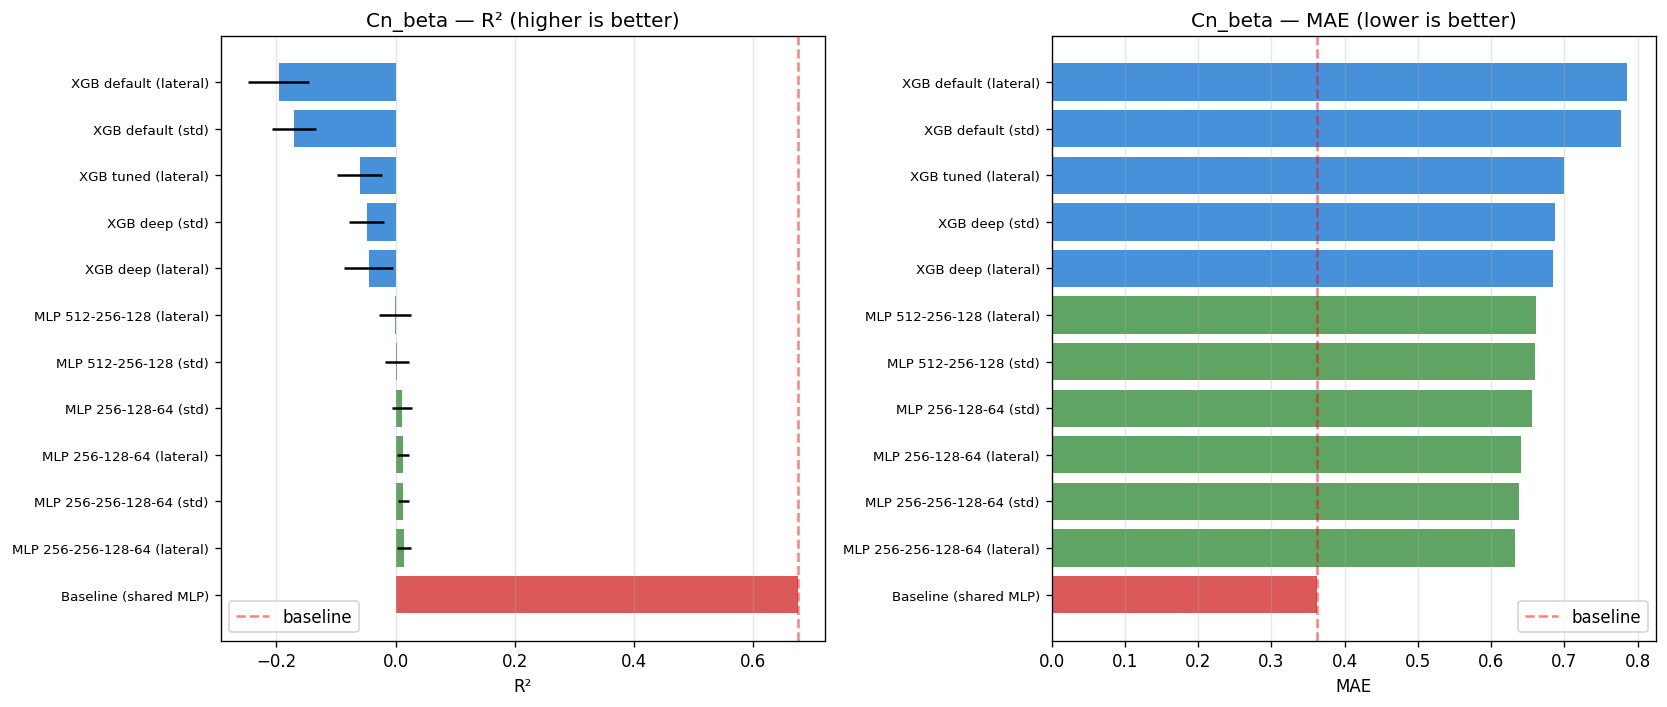

In [9]:
# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names = [n for n, _ in sorted_results]
r2_means = [v[0].mean() for _, v in sorted_results]
r2_stds = [v[0].std() for _, v in sorted_results]
mae_means = [v[1].mean() for _, v in sorted_results]

colors = ['#d32f2f' if 'Baseline' in n else
          '#1976d2' if 'XGB' in n else '#388e3c' for n in names]

y_pos = np.arange(len(names))

ax1.barh(y_pos, r2_means, xerr=r2_stds, color=colors, alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(names, fontsize=8)
ax1.set_xlabel('R²')
ax1.set_title('Cn_beta — R² (higher is better)')
ax1.axvline(x=r2_base, color='red', linestyle='--', alpha=0.5, label='baseline')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

ax2.barh(y_pos, mae_means, color=colors, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(names, fontsize=8)
ax2.set_xlabel('MAE')
ax2.set_title('Cn_beta — MAE (lower is better)')
ax2.axvline(x=mae_base, color='red', linestyle='--', alpha=0.5, label='baseline')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature importance (best model)

Top 20 features for Cn_beta:
   1. body_aspect_ratio               importance=0.0345
   2. total_twist                     importance=0.0267
   3. mac                             importance=0.0265
   4. body_yaw_moment                 importance=0.0262 [LATERAL]
   5. body_wetted_area                importance=0.0244
   6. body_side_area                  importance=0.0238 [LATERAL]
   7. aspect_ratio                    importance=0.0236
   8. camber_root                     importance=0.0224
   9. ac_offset                       importance=0.0205
  10. span_body_ratio                 importance=0.0200
  11. qc_sweep                        importance=0.0196
  12. body_twist                      importance=0.0194
  13. sweep_yaw_factor                importance=0.0184 [LATERAL]
  14. dihedral_tip                    importance=0.0183
  15. tip_chord                       importance=0.0181
  16. body_frontal_area               importance=0.0181
  17. twist_gradient                  importa

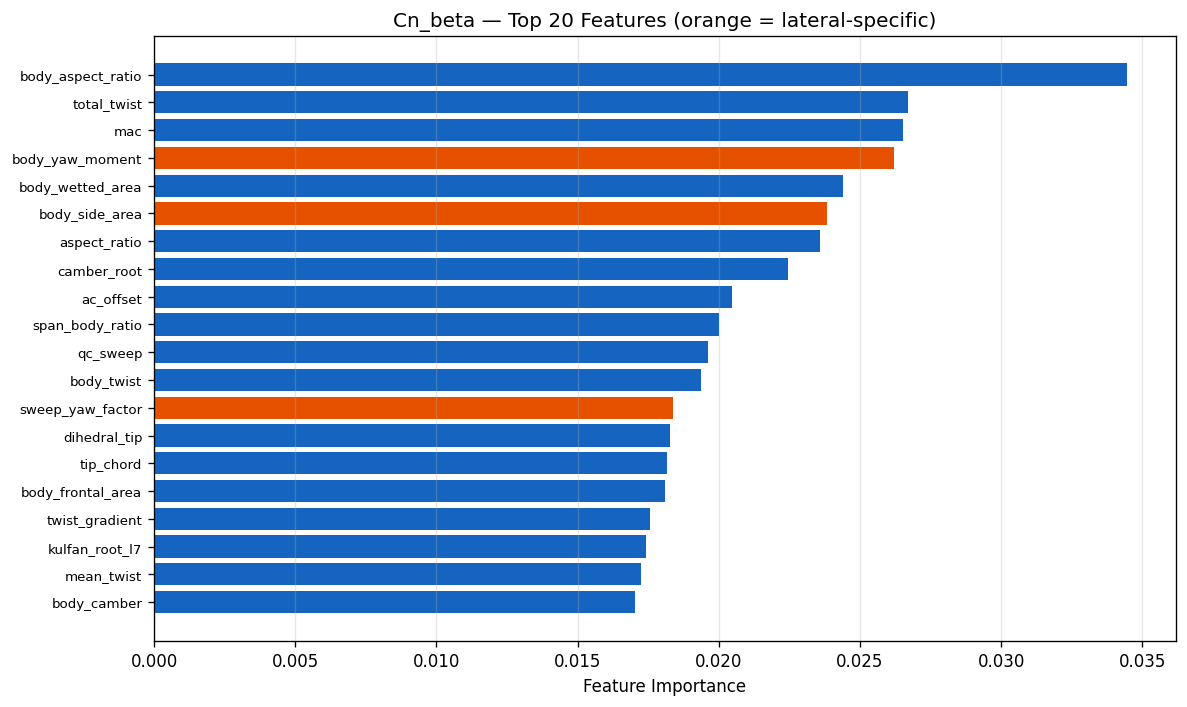

In [10]:
if HAS_XGB:
    # Train best XGB config on full dataset for feature importance
    best_xgb_name = [n for n, _ in sorted_results if 'XGB' in n][0]
    best_xgb_params = dict([c for c in xgb_configs if c[0] == best_xgb_name][0][2])
    best_X = X_lat  # assume lateral features
    
    xgb_full = XGBRegressor(**best_xgb_params, random_state=42, verbosity=0)
    xgb_full.fit(best_X, y_cn)
    
    # Feature names
    from src.parameterization.design_variables import VAR_NAMES
    
    std_derived = [
        'wing_area', 'aspect_ratio', 'mac', 'tip_chord', 'body_root_chord',
        'outer_span', 'total_twist', 'twist_gradient', 'mean_twist',
        'effective_span', 'qc_sweep', 'reflex_root', 'camber_root',
        'ac_offset', 'taper_elliptic_dev', 'body_volume', 'body_frontal_area',
        'body_wetted_area', 'body_aspect_ratio', 'blend_tc_mismatch',
        'body_sweep_total', 'span_body_ratio',
    ]
    all_feat_names = list(VAR_NAMES) + std_derived + lat_names
    
    importances = xgb_full.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    
    print('Top 20 features for Cn_beta:')
    for rank, idx in enumerate(sorted_idx[:20]):
        name = all_feat_names[idx] if idx < len(all_feat_names) else f'feat_{idx}'
        is_lateral = idx >= 52
        tag = ' [LATERAL]' if is_lateral else ''
        print(f'  {rank+1:>2}. {name:<30s}  importance={importances[idx]:.4f}{tag}')
    
    # Plot top 20
    fig, ax = plt.subplots(figsize=(10, 6))
    top_idx = sorted_idx[:20]
    top_names = [all_feat_names[i] if i < len(all_feat_names) else f'feat_{i}' 
                 for i in top_idx]
    top_imp = importances[top_idx]
    colors_fi = ['#e65100' if i >= 52 else '#1565c0' for i in top_idx]
    
    ax.barh(range(len(top_names)), top_imp[::-1], color=colors_fi[::-1])
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Cn_beta — Top 20 Features (orange = lateral-specific)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Parity plot — Best model vs baseline

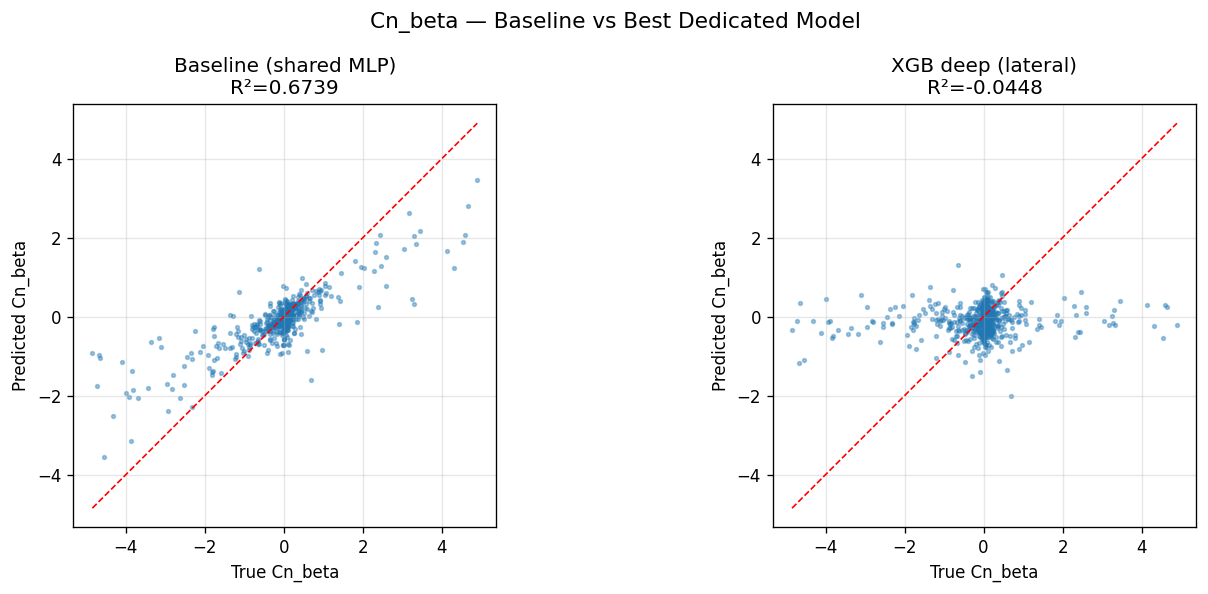

In [11]:
# Train best model on 80% and plot parity on held-out 20%
rng = np.random.default_rng(42)
perm = rng.permutation(len(y_cn))
n_test = len(y_cn) // 5
test_idx = perm[:n_test]
train_idx = perm[n_test:]

X_test_raw = X_clean[test_idx]
y_test = y_cn[test_idx]

# Baseline predictions
preds_test_base = surrogate_base.predict(X_test_raw)['Cn_beta']

# Best dedicated model predictions
if HAS_XGB:
    X_lat_full, _ = augment_lateral_features(X_clean)
    xgb_parity = XGBRegressor(**best_xgb_params, random_state=42, verbosity=0)
    xgb_parity.fit(X_lat_full[train_idx], y_cn[train_idx])
    y_pred_best = xgb_parity.predict(X_lat_full[test_idx])
    best_label = best_xgb_name
else:
    # Use best MLP config
    best_mlp_name = sorted_results[0][0]
    best_label = best_mlp_name
    # Retrain for parity (simplified - use lateral features)
    scX = StandardScaler().fit(X_lat[train_idx])
    scy = StandardScaler().fit(y_cn[train_idx].reshape(-1, 1))
    model_p, _ = train_single_mlp(
        scX.transform(X_lat[train_idx]),
        scy.transform(y_cn[train_idx].reshape(-1, 1)).ravel(),
        scX.transform(X_lat[test_idx]),
        scy.transform(y_cn[test_idx].reshape(-1, 1)).ravel(),
        (256, 256, 128, 64), epochs=500)
    with torch.no_grad():
        y_pred_s = model_p(torch.tensor(
            scX.transform(X_lat[test_idx]), dtype=torch.float32, device=device
        )).cpu().numpy().ravel()
    y_pred_best = scy.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (ax1, preds_test_base, f'Baseline (shared MLP)\nR²={r2_base:.4f}'),
    (ax2, y_pred_best, best_label),
]:
    ss_res = np.sum((y_test - y_pred)**2)
    ss_tot = np.sum((y_test - y_test.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    ax.scatter(y_test, y_pred, s=5, alpha=0.4)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    if 'Baseline' not in title:
        title = f'{title}\nR²={r2:.4f}'
    ax.set_title(title)
    ax.set_xlabel('True Cn_beta')
    ax.set_ylabel('Predicted Cn_beta')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Cn_beta — Baseline vs Best Dedicated Model', fontsize=13)
plt.tight_layout()
plt.show()